### Sistema Recomendación Híbrido

El objetivo de este proyecto es construir un sistema de recomendación basado en las compras realizadas por los clientes de una superficie comercial. El enfoque parte de una restricción clave: al tratarse de compra física, no es posible recomendar en tiempo real durante la compra, ya que no conocemos la cesta del cliente hasta que pasa por caja. Esto diferencia el problema del de una tienda online, donde sí se puede recomendar según la cesta se va componiendo.
Por ello, el sistema se orienta a la recomendación entre visitas: a partir del historial de compra de cada cliente, generar recomendaciones personalizadas que incentiven su siguiente visita (mediante email, app o cupones en el ticket), en línea con los programas de fidelización habituales en el sector.
Para ello se construyen dos modelos:

- ALS, que aprende los hábitos de cada cliente a partir de su historial para predecir y recomendar su próxima compra. Es el núcleo de la personalización.
- Popularidad, que recomienda los productos más vendidos como red de seguridad para clientes nuevos o sin historial suficiente.

### Librerías

In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

In [2]:
import pandas as pd
import numpy as np
# ALS
from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix
# Optimización
import optuna

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

In [3]:
df = pd.read_pickle('data/transacciones_limpio.pkl')
print('Datos cargados correctamente')
df.head(5)

Datos cargados correctamente


,line_id,ticket_number,user_card_id,payment_method,shop_name,shop_address,product_code,product_name,seccion,units,price_per_unit,price_total,created_at
0,9526401,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1063,HELADO CHOCOLATE 1L,Congelados,1,3.38,3.38,2025-01-01 08:20:00
1,9526398,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1122,ACEITUNAS RELLENAS 350G,Snacks,3,1.77,5.31,2025-01-01 08:20:00
2,9526399,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1123,PALOMITAS MICROONDAS PACK 3,Snacks,1,2.27,2.27,2025-01-01 08:20:00
3,9526400,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1124,NACHOS 200G,Snacks,1,1.96,1.96,2025-01-01 08:20:00
4,9526403,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1070,CROQUETAS JAMON 500G,Precocinados,2,3.17,6.34,2025-01-01 08:20:00


Comprobamos longitud datos y fecha mínima y máxima para realizar división de datos

In [4]:
print(f'Filas: {len(df):,}')
print(df.created_at.min())
print(df.created_at.max())

Filas: 100,000
2025-01-01 08:20:00
2025-06-30 21:58:00


Tras comprobar fechas procedemos a separar los datos y crear un conjunto de entrenamiento y testeo. Esta separación se realiza de forma manual.

In [5]:
# Fecha corte. Últimos 30 días para test
fecha_corte = df.created_at.max() - pd.Timedelta(days=30)
print(f'Fecha corte: {fecha_corte}')

# creamos conjuntos
train = df[df.created_at <= fecha_corte].copy()
test = df[df.created_at > fecha_corte].copy()

print(f'Longitud Train: {len(train)}; ({len(train)/len(df)*100:.0f}%)') 
print(f'Longitud Test: {len(test)}; ({len(test)/len(df)*100:.0f}%)')
print('-'*50)
print(f'Tickets train: {train.ticket_number.nunique():,}') # comprobación de tickets por conjunto
print(f'Tickets test: {test.ticket_number.nunique():,}')


Fecha corte: 2025-05-31 21:58:00
Longitud Train: 83443; (83%)
Longitud Test: 16557; (17%)
--------------------------------------------------
Tickets train: 7,944
Tickets test: 1,596


Ahora vamos a comprobar el número de clientes evaluables. Este paso es importante porque determina la frontera a partir de la cual entra en juego cada modelo. Para ALS, un sistema personalizado, se necesita un registro histórico del cliente por tanto no funcionará con aquellos clientes nuevos, lo que se conoce como cold start. Estos clientes nuevos, son aquellos que solo figuran en el conjunto de test y por tanto no tienen historial previo.

In [6]:
# almacenamos los clientes en conjuntos y eliminamos duplicados
clientes_train = set(train.user_card_id.unique())
clientes_test = set(test.user_card_id.unique())

evaluables = clientes_test & clientes_train # intersección que guarda solo clientes que se encuentran en ambos conjuntos. Aparecen tanto en train como test
cold_start = clientes_test - clientes_train  # clientes que compraron por primera vez dentro del rango de test.

print(f'Clientes en test: {len(clientes_test)}')
print(f'Evaluables: {len(evaluables)}') # clientes sobre los que se puede probar ALS
print(f'Cold start puro (test): {len(cold_start)}')

Clientes en test: 1083
Evaluables: 998
Cold start puro (test): 85


Con estos cálculos ya tenemos una idea sobre la cantidad de clientes que vamos a manejar en las evaluaciones de modelos.
Contamos con 1083 clientes dentro del conjunto de testeo de los cuales, 85 de ellos han realizado su primera compra en el periodo que contempla el conjunto de test. Los restantes 998 clientes se encuentran en ambos conjuntos y nos ayudarán a desarrollar ALS. 

In [7]:
# Productos comprados por cada cliente en test
compras_test = test.groupby('user_card_id')['product_name'].apply(set)

# Productos comprados por cada cliente en train
compras_train = train.groupby('user_card_id')['product_name'].apply(set)

### Modelo Basado en Popularidad

El primer modelo que se construye es un sistema NO personalizado. Este modelo solo se va a fijar en cuantas veces aparece cada producto en cada ticket. Se trata de un modelo totalmente sencillo que no necesita conocer ningún cliente, es ideal para cuando estamos empezando o el cliente es nuevo, se usa como referencia base.

In [8]:
# Ranking de productos más populares en conjunto train.
popularidad = train.groupby('product_name')['ticket_number'].nunique().sort_values(ascending=False)

def popularidad_producto(cliente, n=10, filtrar=True):
    """
    Función que recomienda los n productos más populares que el cliente aún no ha comprado en conjunto train.

    Parámetros:
    cliente: ID de cada cliente
    n: número de recomendaciones a devolver
    filtrar: True para excluir productos ya comprados por el cliente en la recomendación.

    Devuelve lista de productos recomendados
    """
    productos_comprados = compras_train.get(cliente, set()) if filtrar else set() # recuperamos productos comprados en train por cada cliente
    recomendaciones = [product for product in popularidad.index if product not in productos_comprados] # se genera la recomendación de productos que no se encuentren dentro de los comprados en train
    return recomendaciones[:n]



Se crea una variable en donde se almacenan los productos comprados en cada ticket, esta variable queda excluida de la función para evitar recalcular en cada llamada a la función a esta variable. 

Dentro de la función, se filtran los productos comprados en el conjunto train. El filtrado dependerá de si la condición filtrar es True (valor por defecto). De esta forma, se evita recomendar productos que el cliente ya ha comprado para así recomendarle nuevos productos.

In [9]:
ejemplo = list(evaluables)[0]
print(popularidad_producto(ejemplo, n=10))

['CARNE PICADA MIXTA 500G', 'TOMATE FRITO 400G', 'CEBOLLA KG', 'PATATA KG', 'PASTA ESPAGUETI 500G', 'GALLETAS MARIA 800G', 'REFRESCO COLA 2L', 'MANZANA GOLDEN KG', 'FRIEGASUELOS 1.5L', 'LECHUGA ICEBERG UD']


In [10]:
def evaluar_modelo(funcion_recomendar, clientes, k=10, **kwargs):
    """
    Función para evaluar un modelo de recomendación con métricas Precision@k y Recall@k.
    
    Parámetros:
    función_recomendar: función que contiene un sistema recomendador
    clientes: lista de clientes que se van evaluar
    k = nº de recomendaciones a considerar por cliente
    **kwargs: argumentos adicionales incluidos en funcion_recomendar.

    Devuelve los valores medios de Precision y Recall.
    """
    # iniciamos listas para guardar punutación de cada cliente
    precisiones = [] 
    recalls = []

    # bucle para recorrer cada cliente
    for cliente in clientes:
        recomendados = set(funcion_recomendar(cliente, n=k, **kwargs))
        comprados = compras_test.get(cliente, set()) # recuperamos productos comprados de conjunto test

        if len(comprados) == 0: # si no hay productos comprados indicamos que siga
            continue

        aciertos = len(recomendados & comprados)
        precisiones.append(aciertos / k)
        recalls.append(aciertos / len(comprados))

    return np.mean(precisiones), np.mean(recalls)

Creamos una función para evaluar los modelos de forma genérica que calcula Precision@K y Recall@K. Como recibe la función de recomendación en los parámetros, nos permite pevaluar cualquier modelo con el mismo código.

In [11]:
prec_filtro, rec_filtro = evaluar_modelo(popularidad_producto, evaluables, k=10, filtrar=True)

print(f'Popularidad con filtro: Precision@10= {prec_filtro:.4f} Recall@10={rec_filtro:.4f}')

Popularidad con filtro: Precision@10= 0.1249 Recall@10=0.0912


In [12]:
# # Recomendaciones del baseline para varios clientes evaluables
# for cliente in list(evaluables)[:5]:
#     recomendados = popularidad_producto(cliente, n=5, filtrar=True)
#     ya_compra = compras_train.get(cliente, set())
    
#     print(f"Cliente {cliente}")
#     print(f"  Ya compraba (train): {list(ya_compra)[:6]}")
#     print(f"  Le recomendamos:     {recomendados}")
#     print()

### ALS

Con el sistema basado en la popularidad de los productos como baseline desarrollado, pasamos al sistema más complejo, ALS, en donde se busca realizar recomendaciones personalizadas a cada cliente en base a sus gustos personales.

La idea central de este algoritmo es la factorización de matrices. Para ello partimos de una matriz cliente-producto, que en general suele ser una tabla de gran tamaño que se encuentra principalmente vacía, ya que cada celda muestra el número de veces que el cliente compró cada producto. En un entorno real, es lógico que cada cliente va a comprar una serie de productos específicos y no todo el catálogo de productos, de ahí que se encuentre principalmente vacía.

Una vez tenemos esta tabla/matriz, ALS busca descomponer la matriz en dos matrices más pequeñas, una de clientes y otra de productos, descritas por factores latentes. Los factores latentes son características ocultas que el modelo inventa para explicar los datos. Similar al ajuste de parámetros en un modelo de ML clásico.
Con las dos matrices ya separadas, ALS procede a fijar una de ellas para calcular la otra. Una vez resuelve una de ellas procede a bloquear la otra matriz para resolver la que se encuentra pendiente. Con esto se procede a realizar la predicción, que consiste en multiplicar los vectores de factores.

En primer lugar, vamos a construir la matriz dispersa de cliente-producto

In [13]:
def construir_matriz(train):
    """
    Función que construye matriz dispera a partir de la frecuencia de compra del conjunto train.
    """

    # frecuencia de compra
    interacciones = (
        train.groupby(['user_card_id', 'product_name'])
        .size()
        .reset_index(name='frecuencia')
    )

    # lista de valores únicos para clientes y productos
    clientes_unicos = interacciones['user_card_id'].unique()
    productos_unicos = interacciones['product_name'].unique()

    # mapeo de valores
    cliente_idx = {c: i for i, c in enumerate(clientes_unicos)} #asignaos valor único a cada cliente
    producto_idx = {p: i for i, p in enumerate(productos_unicos)} # asignamos valor único a cada producto
    idx_producto = {i: p for p, i in producto_idx.items()}

    # matriz dispersa
    filas = interacciones['user_card_id'].map(cliente_idx)
    columnas = interacciones['product_name'].map(producto_idx)
    valores = interacciones['frecuencia'].astype(float)

    matriz = csr_matrix(
        (valores, (filas,columnas)),
        shape=(len(clientes_unicos), len(productos_unicos))
    )

    return matriz, cliente_idx, producto_idx, idx_producto 




In [14]:
matriz_cp, cliente_idx, producto_idx, idx_producto = construir_matriz(train)

print(f'Forma: {matriz_cp.shape}')
print(f'Densidad: {matriz_cp.nnz / (matriz_cp.shape[0]*matriz_cp.shape[1])*100:.2f}%')

Forma: (2197, 138)
Densidad: 15.17%


Una vez se ha construido la matriz, vamos a entrenar un modelo base que simplemente cuenta con los valores por defecto. Luego se procederá a optimizar el modelo mediante Optuna en búsqueda de unos mejores parámetros.

In [15]:
modelo_als_base = AlternatingLeastSquares(random_state=42)
modelo_als_base.fit(matriz_cp)

print('Modelo base entrenado')
print(f'Factores por defecto: {modelo_als_base.factors}')

  0%|          | 0/15 [00:00<?, ?it/s]

Modelo base entrenado
Factores por defecto: 100


Con el modelo base instanciado, vamos a crear una función similar a popularidad_producto pero enfocada en ALS. De esta forma evitamos repetir código de forma innecesaria

In [16]:
def recomendar_als(cliente, n=10, filtrar=True, modelo=None):
    """
    Función que recomienda n productos para un cliente mediante ALS

    Parámetros
    cliente: cliente a evaluar
    n: nº de recomendaciones
    filtrar: True por defecto para no recomendar productos ya comprados
    modelo: None por defecto. Se indica manualmente que modelo de ALS se quiere emplear.
    """

    c_idx = cliente_idx[cliente]
    ids, _ = modelo.recommend(
        c_idx,
        matriz_cp[c_idx],
        N=n,
        filter_already_liked_items=filtrar
    )

    return [idx_producto[i] for i in ids]

In [17]:
prec_als_base, rec_als_base = evaluar_modelo(recomendar_als, evaluables, k=10, filtrar=True, modelo=modelo_als_base)
print(f"ALS base (con filtro): Precision@10={prec_als_base:.4f}  Recall@10={rec_als_base:.4f}")

ALS base (con filtro): Precision@10=0.0722  Recall@10=0.0574


Como era de esperar, un modelo base sin optimizar devuelve unos resultados pobres. Una vez actualicemos el modelo, es esperable obtener unos mejores resultados. La cuestión es que para un catálogo de 138 productos, 100 factores latentes es una cifra muy grande.

Con esto en mente vamos a proceder con la optimmización del modelo.

In [18]:
def objetivo(trial):
    # creamos espacio de búsqueda
    factors = trial.suggest_int('factors', 2, 30)
    regularization = trial.suggest_float('regularization', 0.001, 1.0, log=True)
    alpha = trial.suggest_float('alpha', 1.0, 40.0)
    iterations = trial.suggest_int('iterations', 10, 40)

    modelo = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        alpha=alpha,
        iterations=iterations,
        random_state=42
    )
    modelo.fit(matriz_cp)

    prec, _ = evaluar_modelo(recomendar_als, evaluables, k=10, filtrar=True, modelo=modelo)
    return prec

In [19]:
optuna.logging.set_verbosity(optuna.logging.WARNING)  # menos ruido en la salida

study = optuna.create_study(direction="maximize")
study.optimize(objetivo, n_trials=30, show_progress_bar=True)

print(f'Mejor Precision@10: {study.best_value:.4f}')
print(f'Mejores parámetros: {study.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Mejor Precision@10: 0.2445
Mejores parámetros: {'factors': 7, 'regularization': 0.19684369308100516, 'alpha': 3.7128605668269596, 'iterations': 19}


In [20]:
modelo_als_optimizado = AlternatingLeastSquares(
    **study.best_params,
    random_state=42
)
modelo_als_optimizado.fit(matriz_cp)

prec_als_opt, rec_als_opt = evaluar_modelo(recomendar_als, evaluables, k=10, filtrar=True, modelo=modelo_als_optimizado)
print(f"ALS final: Precision@10={prec_als_opt:.4f}  Recall@10={rec_als_opt:.4f}")

  0%|          | 0/19 [00:00<?, ?it/s]

ALS final: Precision@10=0.2445  Recall@10=0.1819


In [21]:
for cliente in list(evaluables)[:6]:
    recomendados = recomendar_als(cliente, n=5, filtrar=True, modelo=modelo_als_optimizado)
    ya_compra = compras_train.get(cliente, set())
    
    print(f"Cliente {cliente}")
    print(f"  Compra habitual: {list(ya_compra)[:6]}")
    print(f"  Le recomendamos: {recomendados}")
    print()

Cliente 100352
  Compra habitual: ['CAFE MOLIDO 250G', 'TOMATE RAMA KG', 'LECHE ENTERA BRIK 1L', 'TE VERDE 25 BOLSAS', 'AZUCAR BLANCO 1KG', 'MERMELADA FRESA 350G']
  Le recomendamos: ['GALLETAS MARIA 800G', 'TOMATE FRITO 400G', 'CARNE PICADA MIXTA 500G', 'HARINA TRIGO 1KG', 'PASTA ESPAGUETI 500G']

Cliente 102402
  Compra habitual: ['SUSHI BANDEJA 12 PIEZAS', 'NACHOS 200G', 'PIZZA JAMON Y QUESO', 'AGUA CON GAS 1L', 'PATATAS FRITAS BOLSA 150G', 'GALLETAS CHOCOLATE 300G']
  Le recomendamos: ['HELADO CHOCOLATE 1L', 'PIZZA CONGELADA 4 ESTACIONES', 'EMPANADA ATUN', 'ACEITUNAS RELLENAS 350G', 'CERVEZA PACK 6']

Cliente 102403
  Compra habitual: ['TOMATE RAMA KG', 'BEBIDA SOJA 1L', 'PATATA KG', 'ZANAHORIA KG', 'HAMBURGUESA VEGETAL PACK 2', 'CARNE PICADA MIXTA 500G']
  Le recomendamos: ['PLATANO KG', 'GAMBA FRESCA KG', 'FILETE TERNERA KG', 'MERLUZA FILETE KG', 'CEREALES DESAYUNO 500G']

Cliente 102404
  Compra habitual: ['PIZZA CONGELADA 4 ESTACIONES', 'CERVEZA PACK 6', 'NACHOS 200G', 'VINO BL

Una vez tenemos los resultados de cada modelo, vamos a almacenarlos en un DataFrame para poder realizar comparaciones entre ellos. Para poder realizar estas comparaciones ambos modelos están filtrados con una condición, no volver a recomendar productos ya comprados por el cliente. La idea de aplicar este filtro es intentar que el cliente descubra nuevos productos. Mediante el descubrimiento de nuevos productos puede que se encuentre algún producto complementario, lo que puede provocar un aumento del carrito de compra.

In [22]:
# Almacenamos resultados
tabla_resultados = pd.DataFrame(
    [
        ['Popularidad Producto (con filtro)', round(prec_filtro,3), round(rec_filtro,3)],
        ['ALS Base',  round(prec_als_base,3), round(rec_als_base,3)],
        ['ALS Optimizado', round(prec_als_opt,3), round(rec_als_opt,3)]
    ],
    columns=['Modelo','Precision@K','Recall@K']
)

tabla_resultados

,Modelo,Precision@K,Recall@K
0,Popularidad Producto (con filtro),0.125,0.091
1,ALS Base,0.072,0.057
2,ALS Optimizado,0.244,0.182


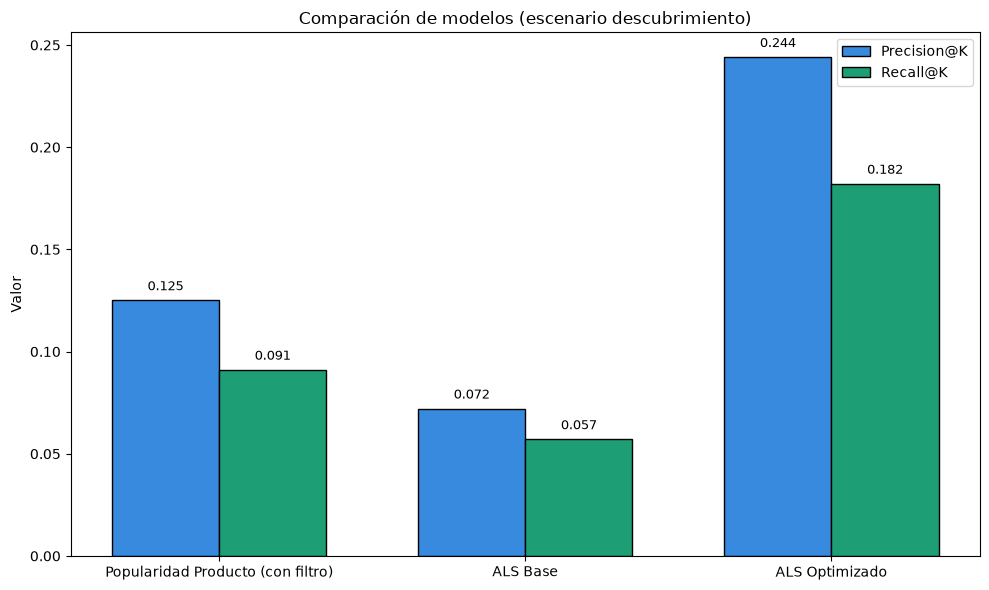

In [23]:
modelos = tabla_resultados["Modelo"]
x = np.arange(len(modelos))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - ancho/2, tabla_resultados["Precision@K"], ancho, label="Precision@K", color="#378ADD", edgecolor='black')
ax.bar(x + ancho/2, tabla_resultados["Recall@K"], ancho, label="Recall@K", color="#1D9E75", edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylabel("Valor")
ax.set_title("Comparación de modelos (escenario descubrimiento)")
ax.legend()

# Etiquetas de valor sobre cada barra
for i, (p, r) in enumerate(zip(tabla_resultados["Precision@K"], tabla_resultados["Recall@K"])):
    ax.text(i - ancho/2, p + 0.005, f"{p:.3f}", ha="center", fontsize=9)
    ax.text(i + ancho/2, r + 0.005, f"{r:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

La comparación de los tres modelos permite extraer varias conclusiones.

El baseline establecido en el modelo de popularidad de productos, pese a la sencillez del mismo, obtiene un rendimiento aceptable, con un valor de Precision@K (para este ejemplo 10) de 0.125. Es importante tener en cuenta que los modelos cuentan con un filtro en donde se busca recomendar productos nuevos, nunca productos que ya hubiesen sido comprados por el cliente.

Observando los resultados de ALS sin optimizar, este modelo tiene un rendimiento más bajo que el modelo basado en popularidad. Este resultado no implica que ALS sea peor modelo en este escenario, el problema se encuentra en la configuración empleada, los valores por defecto, que trabaja con 100 factores latentes, un tamaño excesivo para un catálogo de 138 productos.

Por el contrario, con el modelo ALS optimizado, este logra alcanzar una Precision@K de 0.246, que prácticamente duplica el baseline. La optimización logra reducir los factores latentes a 6, coherente con el tamaño del catálogo.

Con estos datos, la conclusión principal es que cuando existe diferenciación real entre los perfiles de cliente, un modelo de filtrado colaborativo como ALS logra aportar más valor que un modelo con enfoque no personalizado. La personalización no solo logra mejorar las métricas finales, sino que también permite realizar recomendaciones más ajustadas al perfil de cada cliente.

Es importante tener en cuenta que no estamos compitiendo por ver que modelo es mejor, sino que modelo rinde mejor en cada escenario. Como la solución final es un modelo en cascada, la recomendación de popularidad en producto se enfoca para los clientes que no cuentan con historial de compra y por tanto se encuentran en una situación de cold start, mientras que el modelo ALS se construye para trabajar con aquellos clientes que si cuentan con un historial de compra.

La desventaja de un modelo ALS se encuentra en el coste-beneficio que presenta, en donde se requiere de mayor infraestructura, es decir, mayor coste de entrenamiento y reentrenamiento.

**NOTA**

La precision nos indica cuantos productos acertó el cliente a la hora de comprar de entre los productos que hemos recomendado (en este caso 10). Es la métrica estrella en este escenario
El recall por el contrario, nos indica cuantos productos hemos logrado cubrir con las recomendaciones de la cesta total de productos comprada por el cliente. Es importante tener en cuenta que este resultado se encuentra limitado, esto se debe a que recomendamos 10 productos pero un cliente puede tener 20 productos total en su cesta, por tanto nunca se logra cubrir toda la cesta.

### SISTEMA DE CASCADA

Ahora con los dos modelos desarrollados, es momento de construir el sistema de cascada que realizará las recomendaciones según sea la situación de cliente, con historial para ALS y sin historial para popularidad.

In [27]:
def recomendar_hibrido(cliente, n=10, filtrar=True):
    """
    Sistema de recomendación en cascada.
    Si el cliente cuenta con historial se emplea ALS en caso contrario, se emplea popularidad.
    Parámetros:
    cliente: listado de clientes
    n: nº de recomendaciones
    filtrar: True para no recomendar productos ya comprados.
    """

    if cliente in cliente_idx:  # comprobamos que se encuentre en la matriz de train. cliente_idx solo contiene clientes del conjunto train, el que tiene historial.
        productos = recomendar_als(cliente, n=n, filtrar=filtrar, modelo=modelo_als_optimizado)
        return productos, 'als'
    else: # popularidad
        productos = popularidad_producto(cliente, n=n, filtrar=filtrar)
        return productos, 'popularidad productos'

In [29]:
# Cliente con historial
productos, origen = recomendar_hibrido(list(evaluables)[0], n=5)
print(f"Productos: {productos}")
print(f"Origen: {origen}")

Productos: ['GALLETAS MARIA 800G', 'TOMATE FRITO 400G', 'CARNE PICADA MIXTA 500G', 'HARINA TRIGO 1KG', 'PASTA ESPAGUETI 500G']
Origen: als


Para hacer cierta simulación de un proceso automatizado, se va a generar un listado de emails para cada cliente. La idea es enviar por correo a cada cliente la recomendación que se le realiza.

El primer paso es generar la lista de clientes con sus correos. Importante tener en cuenta que este es un paso "ficticio", en un entorno real disponderemos del mail de cada cliente.

In [ ]:
clientes_todos = df['user_card_id'].unique() # rescatamos cada ID
email_clientes = {cliente: f'cliente{cliente}@email.com' for cliente in clientes_todos} # iniciamos bucle para crear mails

{np.int64(101629): 'cliente101629@email.com', np.int64(100085): 'cliente100085@email.com', np.int64(102370): 'cliente102370@email.com', np.int64(100494): 'cliente100494@email.com', np.int64(101571): 'cliente101571@email.com', np.int64(102437): 'cliente102437@email.com', np.int64(100641): 'cliente100641@email.com', np.int64(102428): 'cliente102428@email.com', np.int64(102427): 'cliente102427@email.com', np.int64(100242): 'cliente100242@email.com', np.int64(100584): 'cliente100584@email.com', np.int64(101711): 'cliente101711@email.com', np.int64(101861): 'cliente101861@email.com', np.int64(100767): 'cliente100767@email.com', np.int64(102345): 'cliente102345@email.com', np.int64(101127): 'cliente101127@email.com', np.int64(101335): 'cliente101335@email.com', np.int64(101051): 'cliente101051@email.com', np.int64(102112): 'cliente102112@email.com', np.int64(101336): 'cliente101336@email.com', np.int64(101593): 'cliente101593@email.com', np.int64(102301): 'cliente102301@email.com', np.int64(

In [32]:
def componer_email(cliente, n=5):
    """
    Función que se encarga de componer el texto del email de recomendación para cada cliente
    El mensaje cambia según el tipo de recomendación realizada
    """

    productos, origen = recomendar_hibrido(cliente, n=n)
    email = email_clientes[cliente]

    if origen == 'als':
        intro = 'Basándonos en tus últimas compras, creemos que te puede interesar:'
    else:
        intro = 'Descubre nuestros productos más populares'
    # lista de productos
    lista_productos = '\n'.join(f' -{p}' for p in productos)

    # Texto correo
    cuerpo = f"""Para: {email}
Asunto: Tus recomendaciones de esta semana

Hola {cliente},

{intro}

{lista_productos}

¡Te esperamos en tu próxima visita!
"""
    return cuerpo

In [33]:
# Cliente con historial (ALS)
print(componer_email(list(evaluables)[0]))
print("=" * 50)
# Cliente cold start (popularidad)
print(componer_email(list(cold_start)[0]))

Para: cliente100352@email.com
Asunto: Tus recomendaciones de esta semana

Hola 100352,

Basándonos en tus últimas compras, creemos que te puede interesar:

 -GALLETAS MARIA 800G
 -TOMATE FRITO 400G
 -CARNE PICADA MIXTA 500G
 -HARINA TRIGO 1KG
 -PASTA ESPAGUETI 500G

¡Te esperamos en tu próxima visita!

Para: cliente100872@email.com
Asunto: Tus recomendaciones de esta semana

Hola 100872,

Descubre nuestros productos más populares

 -MERMELADA FRESA 350G
 -AZUCAR BLANCO 1KG
 -CARNE PICADA MIXTA 500G
 -CAFE MOLIDO 250G
 -LECHE ENTERA BRIK 1L

¡Te esperamos en tu próxima visita!



In [36]:
def enviar_batch(clientes, n=5, mostrar=3):
    """
    Genera y envía los correo de recomendación para una lista de clientes

    Parámetros
    mostrar: indica cuentos correos imprime como ejemplo visual
    """

    enviados = 0

    for i, cliente in enumerate(clientes):
        correo = componer_email(cliente, n=n)

        if i < mostrar:
            print(correo)
            print('-'*30)

        enviados += 1

    print(f'Proceso completado: {enviados} correos generados y enviados')
    return enviados


In [37]:
clientes_objetivo = list(evaluables)[:50] + list(cold_start)[:10]
enviar_batch(clientes_objetivo, n=5, mostrar=2)

Para: cliente100352@email.com
Asunto: Tus recomendaciones de esta semana

Hola 100352,

Basándonos en tus últimas compras, creemos que te puede interesar:

 -GALLETAS MARIA 800G
 -TOMATE FRITO 400G
 -CARNE PICADA MIXTA 500G
 -HARINA TRIGO 1KG
 -PASTA ESPAGUETI 500G

¡Te esperamos en tu próxima visita!

------------------------------
Para: cliente102402@email.com
Asunto: Tus recomendaciones de esta semana

Hola 102402,

Basándonos en tus últimas compras, creemos que te puede interesar:

 -HELADO CHOCOLATE 1L
 -PIZZA CONGELADA 4 ESTACIONES
 -EMPANADA ATUN
 -ACEITUNAS RELLENAS 350G
 -CERVEZA PACK 6

¡Te esperamos en tu próxima visita!

------------------------------
Proceso completado: 60 correos generados y enviados


60